In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv("data/raw/AB_NYC_2019.csv")

# 2. Basic EDA (Examples)
# df.info()
# df.describe()
# df.drop(['id', 'name', 'host_name', 'last_review'], axis=1, inplace=True) # Dropping irrelevant vars

# 3. Divide the dataset into Train and Test
# It is best practice to split BEFORE extensive cleaning to avoid data leakage
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# 4. Save the processed datasets
train_set.to_csv("data/processed/clean_train.csv", index=False)
test_set.to_csv("data/processed/clean_test.csv", index=False)

print("Data split and saved to ./data/processed/")

Data split and saved to ./data/processed/


Dimensions: (48895, 16)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  

/tmp/ipykernel_21624/3428705437.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


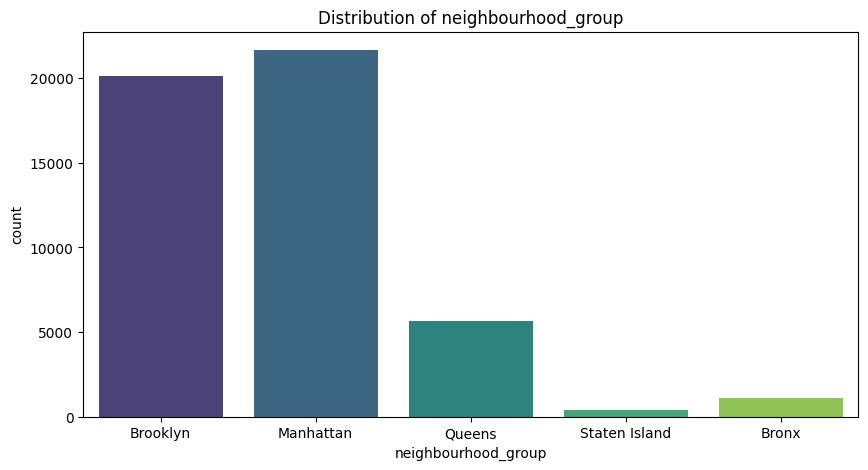

/tmp/ipykernel_21624/3428705437.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')



Value counts for room_type:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


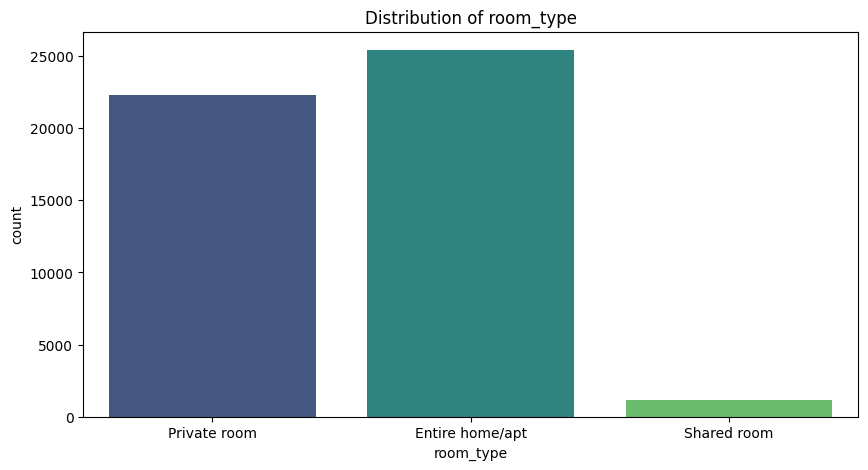


--- Numerical Analysis ---
              price  minimum_nights  number_of_reviews  reviews_per_month  \
count  48895.000000    48895.000000       48895.000000       38843.000000   
mean     152.720687        7.029962          23.274466           1.373221   
std      240.154170       20.510550          44.550582           1.680442   
min        0.000000        1.000000           0.000000           0.010000   
25%       69.000000        1.000000           1.000000           0.190000   
50%      106.000000        3.000000           5.000000           0.720000   
75%      175.000000        5.000000          24.000000           2.020000   
max    10000.000000     1250.000000         629.000000          58.500000   

       calculated_host_listings_count  availability_365  
count                    48895.000000      48895.000000  
mean                         7.143982        112.781327  
std                         32.952519        131.622289  
min                          1.000000         

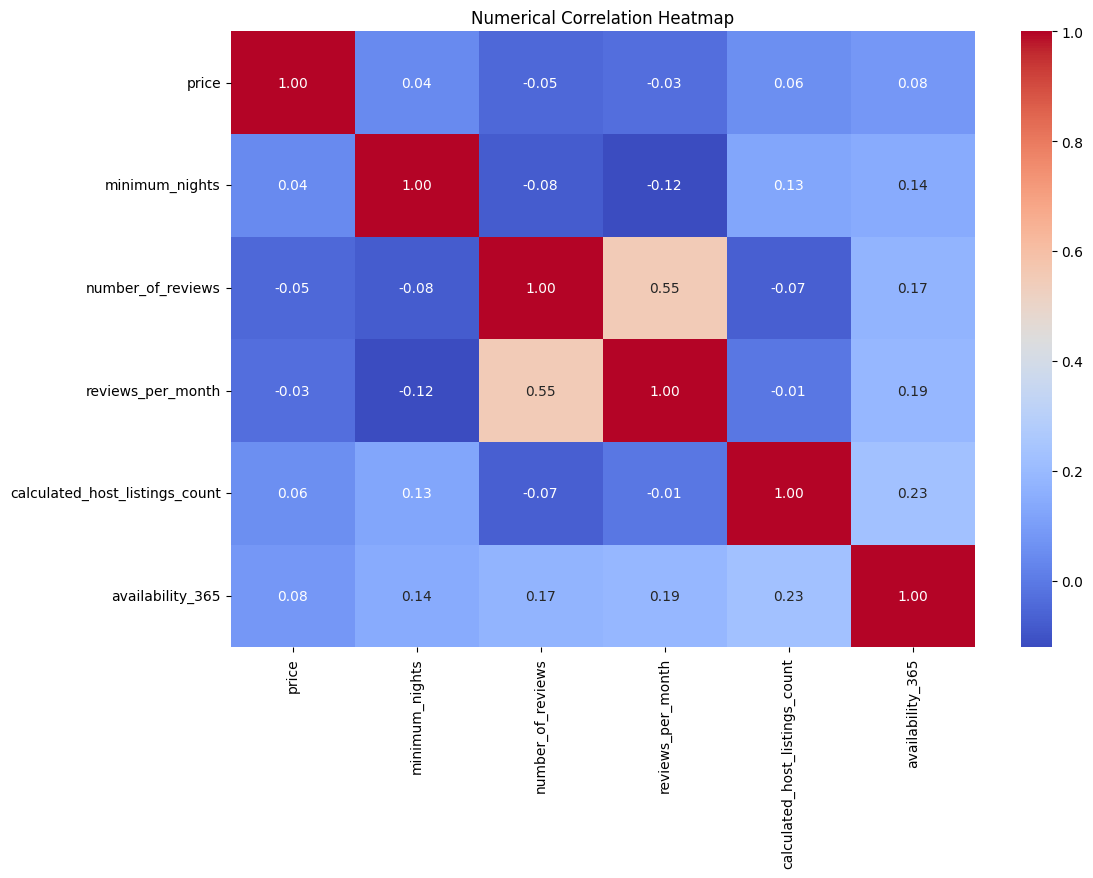

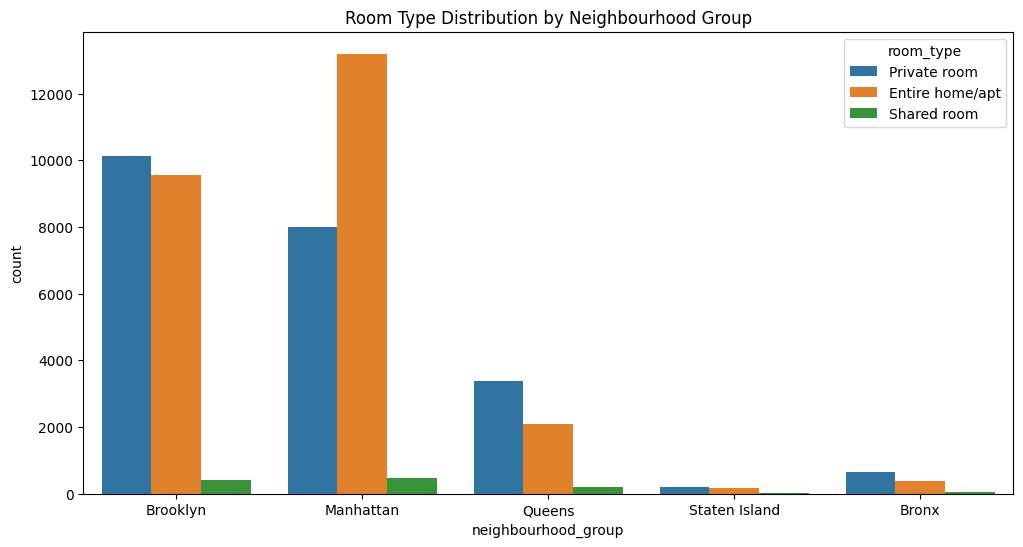

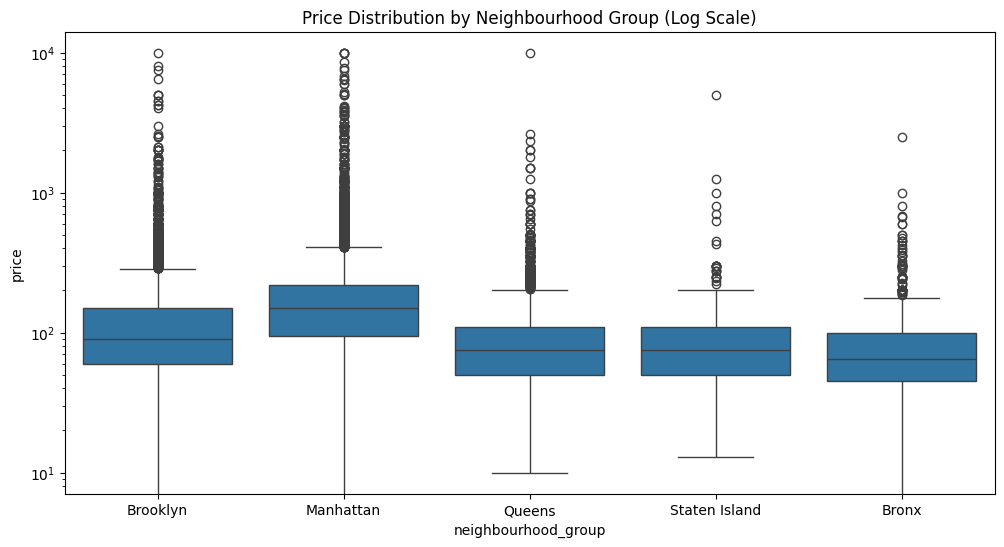

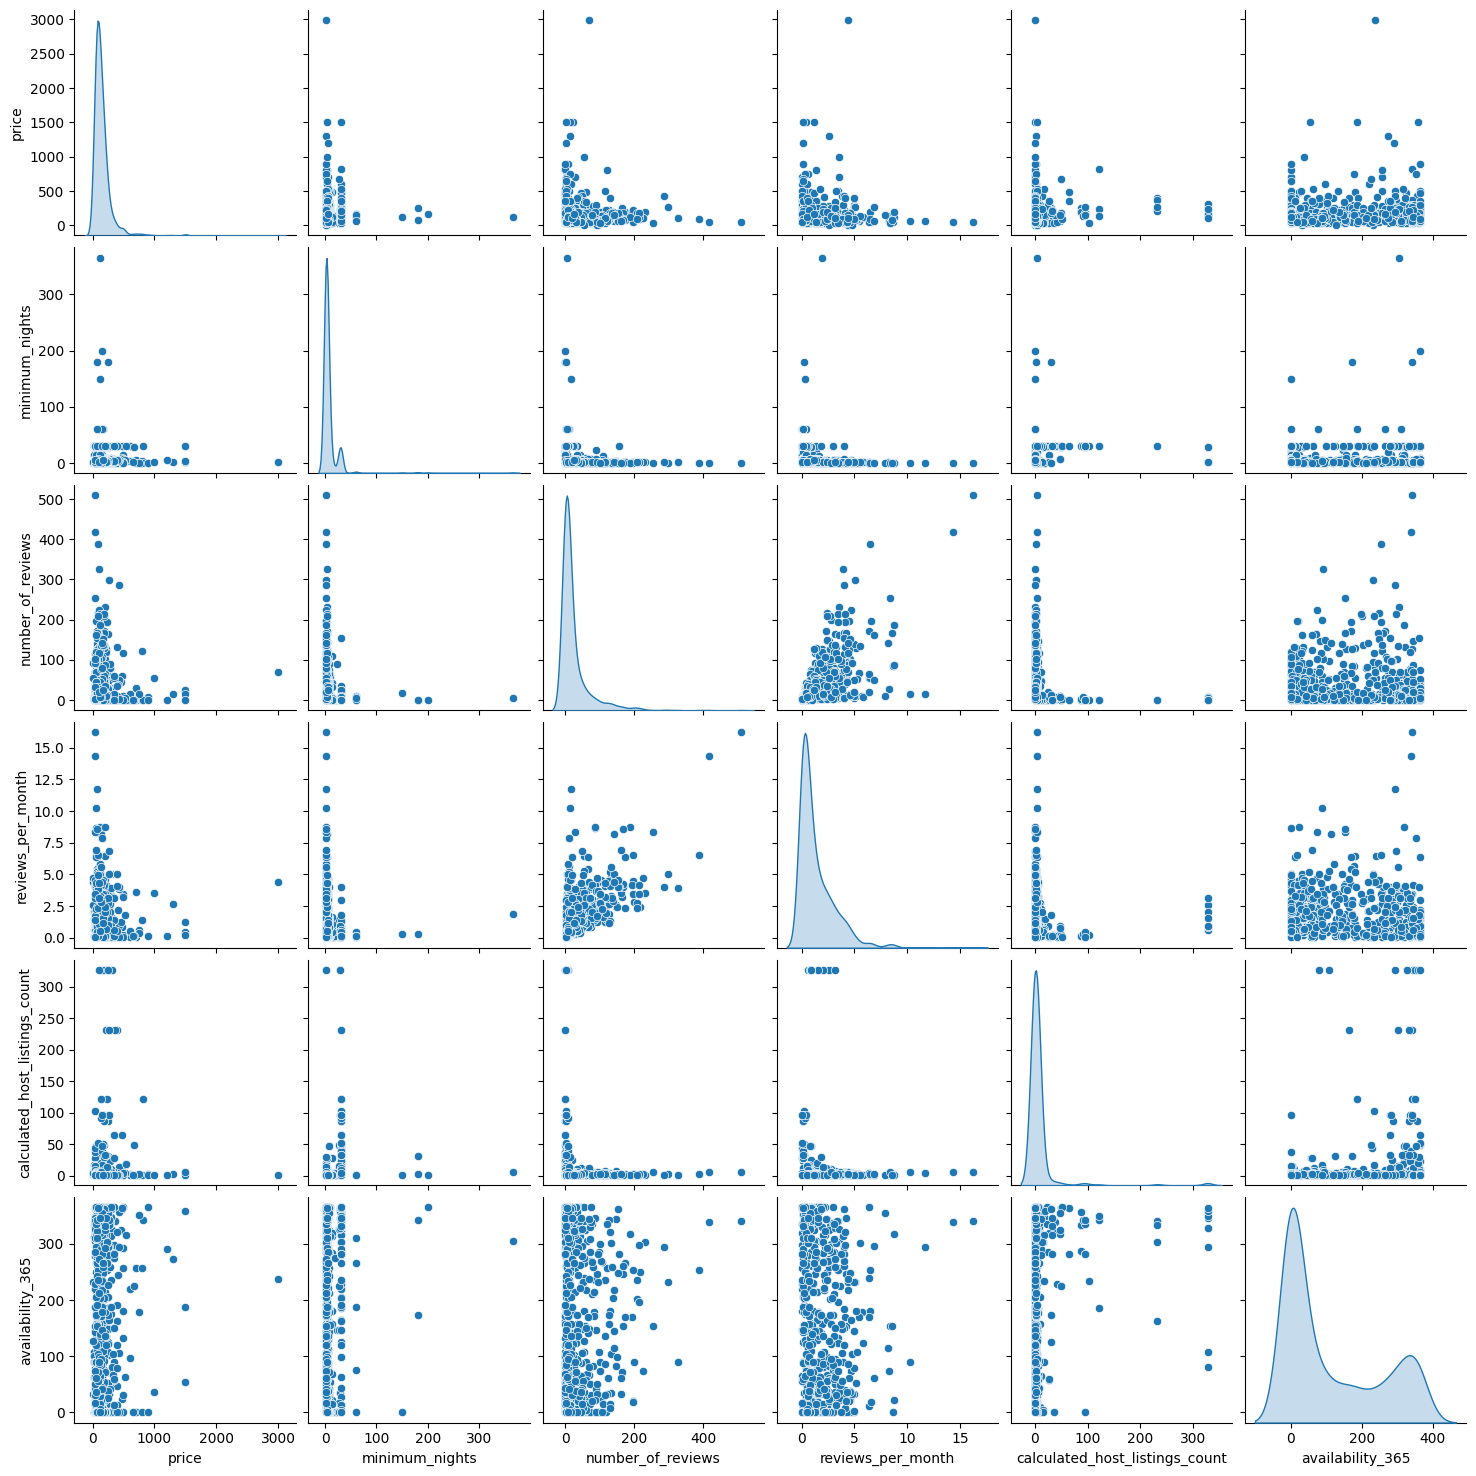


--- Analysis for price ---
Stats: Mean=152.72, Median=106.00
IQR: 106.0
Outliers detected: 2972
Data cleaned. New count: 45923

--- Analysis for minimum_nights ---
Stats: Mean=6.94, Median=2.00
IQR: 4.0
Outliers detected: 6185
Data cleaned. New count: 39738

--- Analysis for number_of_reviews ---
Stats: Mean=26.38, Median=7.00
IQR: 28.0
Outliers detected: 4536

--- Analysis for calculated_host_listings_count ---
Stats: Mean=3.07, Median=1.00
IQR: 1.0
Outliers detected: 3758
Data cleaned. New count: 35980

--- Missing Values ---
host_id                              0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 6266
calculated_host_listings_count       0
availability_365                    

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Load Data
file_name = 'AB_NYC_2019.csv'
df = pd.read_csv("data/raw/AB_NYC_2019.csv")
raw_df = df.copy() # Keep raw data for saving later

# 2. Obtain dimensions
print(f"Dimensions: {df.shape}")

# 3. Information about data types and non-null values
print("\n--- Data Info ---")
df.info()

# 4. Eliminate duplicates
df.drop_duplicates(inplace=True)
print(f"\nDuplicates removed. New dimensions: {df.shape}")

# 5. Eliminate irrelevant columns
irrelevant_cols = ['id', 'name', 'host_name', 'last_review']
df.drop(columns=irrelevant_cols, inplace=True, errors='ignore')

# 6. Analysis on categorical variables
print("\n--- Categorical Analysis ---")
cat_cols = ['neighbourhood_group', 'room_type']
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.show()

# 7. Analysis on numerical variables
print("\n--- Numerical Analysis ---")
num_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
print(df[num_cols].describe())

# 8. Numerical-numerical analysis 
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Correlation Heatmap')
plt.show()

# 9. Categorical-categorical analysis
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='neighbourhood_group', hue='room_type')
plt.title('Room Type Distribution by Neighbourhood Group')
plt.show()

# 10. Complete numerical-categorical analysis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.yscale('log') # Log scale due to high price variance
plt.title('Price Distribution by Neighbourhood Group (Log Scale)')
plt.show()

# 11. Analysing all the data at once
# Using a sample for performance if the dataset is large
sns.pairplot(df[num_cols].sample(min(1000, len(df))), diag_kind='kde')
plt.show()

# Outlier Analysis & Cleaning Function 
def process_outliers(df, col, clean=True):
    print(f"\n--- Analysis for {col} ---")
    print(f"Stats: Mean={df[col].mean():.2f}, Median={df[col].median():.2f}")
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"IQR: {IQR}")
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers detected: {len(outliers)}")
    
    if clean:
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        print(f"Data cleaned. New count: {len(df)}")
    return df

# 12-15. Stats, IQR, and Cleaning for Price
df = process_outliers(df, 'price')

# 16-18. IQR and Cleaning for minimum_nights
df = process_outliers(df, 'minimum_nights')

# 19-21. Stats, IQR for number_of_reviews
process_outliers(df, 'number_of_reviews', clean=False)

# 22-25. Stats, IQR, and Cleaning for calculated_host_listings_count
df = process_outliers(df, 'calculated_host_listings_count')

# 26. Count NaN
print("\n--- Missing Values ---")
print(df.isnull().sum())
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 27. Feature Scaling
scaler = StandardScaler()
df_scaled = df.copy()

# Safely determine which of the expected numeric columns actually exist
numeric_cols = [c for c in num_cols if c in df_scaled.columns]

# Coerce only those columns to numeric (non-numeric -> NaN)
for c in numeric_cols:
    df_scaled[c] = pd.to_numeric(df_scaled[c], errors='coerce')

# Fill NaNs with the column median (computed on the numeric-coerced data)
medians = df_scaled[num_cols].median()
df_scaled[num_cols] = df_scaled[num_cols].fillna(medians)

# Ensure dtype is float before scaling
df_scaled[num_cols] = df_scaled[num_cols].astype(float)

# Fit-transform with StandardScaler
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])
print("\nFeature Scaling complete (StandardScaler applied).")

# 28. Feature Selection
correlation_with_price = df.corr(numeric_only=True)['price'].sort_values(ascending=False)

print("\nCorrelation of features with Price:")
print(correlation_with_price)

# 29. Save the clean and raw data
raw_df.to_csv('AB_NYC_2019_raw_backup.csv', index=False)
df.to_csv('AB_NYC_2019_cleaned.csv', index=False)
print("\nFiles saved successfully: 'AB_NYC_2019_raw_backup.csv' and 'AB_NYC_2019_cleaned.csv'")